In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rnn-11/df_call_detail_records_dec_cut.csv
/kaggle/input/rnn22/df_call_detail_records_nov_cut.csv


# Forecasting Mobile Network (Internet) Traffic in Milan

## Background 

The almost universal adoption of mobile phones and the exponential increase in the use of Internet services is generating an enormous amount of data that can be used to provide new fundamental and quantitative insights on socio-technical systems. This creates a demand to forecast Mobile network traffic so the Internet service providers can estimate how big the bandwidth they need to provide for users so that they can give best services to their customers. 

The following dataset will be used:

**df_call_detail_records_dec_cut.pkl** - Contains the calculation of the level of interaction between users and the mobile phone network with the variables `sms`, `call` and `internet` in each GRID City of Milan in December 2013


Forecasting will be tried on the three variables, `sms`, `call` and `internet`. Or it can also be referred to as multivariate forecasting

## Libraries

In [2]:
# data analysis
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
import tensorflow as tf
import tensorflow.keras as keras

# set seed
import random
random.seed(123)
np.random.seed(123)
tf.random.set_seed(123)

### 1. Reading datafiles


In this section we will build a forecasting model on mobile data traffic dataset recorded in a real-world network that covers a large city of Milan & Province of Trentino, covering the period of December 2013 based on this [paper](https://www.nature.com/articles/sdata201555). Datasets previously available in [txt format](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/EGZHFV) The collected data is quite large, so we stored in a pickle file.

The collected data is stored in a pickle file. Since i cannot run Keras on my local Jupyter Notebook with my M1 Mac. I made this project in Kaggle, but I cannot open the pickle file, I always get an error, even I try this code below:

In [3]:
#open_file = open('../input/dssrnn/df_call_detail_records_dec_cut.pkl', "rb")
#dpkl = pd.DataFrame(open_file)

So I back to my local Jupyter Notebook and run the code below to convert the pickle file to csv.

In [4]:
#df_call = pd.read_pickle('../data_input/df_call_detail_records_dec_cut.pkl').set_index(['datetime'])
#df = pd.DataFrame(df_call)
#df.to_csv(r'../data_input/df_call_detail_records_dec_cut.csv')

In [5]:
df_call = pd.read_csv('../input/rnn-11/df_call_detail_records_dec_cut.csv').set_index(['datetime'])
df_call.head()

,squareid,internet,sms,calls
datetime,,,,
2013-12-01 06:00:00,1,77.283683,2.192212,0.819809
2013-12-01 06:00:00,2,77.465341,2.211839,0.824010
2013-12-01 06:00:00,3,77.658709,2.232732,0.828482
2013-12-01 06:00:00,4,76.757508,2.135362,0.807641
2013-12-01 06:00:00,5,70.700523,2.056988,0.753828


This dataset serves as measure of the level of interaction between the users and the mobile phone network.

- **datetime**: start interval time expressed in milliseconds. The end interval time can be obtained by adding 600,000 milliseconds (10 min) to this value;
- **squareid**: identification string of a given square of Milan/Trentino GRID;
- **sms**: activity proportional to the amount of received and sent SMSs inside a given Square id and during a given Time interval. The SMSs are received and sent from the nation identified by the Country code;
- **call**: activity proportional to the amount of received and issued calls inside the Square id during a given Time interval. The calls are received and issued from the nation identified by the Country code;
- **internet**: number of CDRs generated inside a given Square id during a given Time interval. The Internet traffic is initiated from the nation identified by the Country code;
    + a CDR is generated each time a user starts an Internet connection or ends an Internet connection. During the same connection, a CDR is generated if the connection lasts for more than 15 min or the user transferred more than 5 MB.

**Checking unique number of 'squareid':**

In [6]:
df_call['squareid'].nunique()

9998

The dataset consists of 9998 unique `squareid`. I will proceed all variable `internet`, `sms`, and `calls`  data in the area with the highest total traffic with the code below:

In [7]:
df_call.sort_values('internet',ascending=False)

,squareid,internet,sms,calls
datetime,,,,
2013-12-01 22:00:00,5161,40252.504929,3227.411494,2506.770783
2013-12-01 23:00:00,5161,37046.810177,3053.433762,2580.940768
2013-12-07 23:00:00,5161,34857.472007,4648.682461,4337.729896
2013-12-07 22:00:00,5161,34811.857176,4095.891329,3826.101165
2013-12-01 21:00:00,5161,34593.150069,2261.419349,1968.203682
...,...,...,...,...
2013-12-21 04:00:00,4572,0.000000,0.000000,18.348425
2013-12-21 04:00:00,4573,0.000000,0.000000,2.030084
2013-12-21 04:00:00,4574,0.000000,0.000000,1.860609


In [8]:
df_call.sort_values('sms',ascending=False)

,squareid,internet,sms,calls
datetime,,,,
2013-12-05 00:00:00,4874,7185.844560,5804.560695,2235.067329
2013-12-13 00:00:00,4874,7456.815706,5769.857526,2456.659634
2013-12-12 00:00:00,4874,7397.045378,5460.637696,2397.965940
2013-12-03 00:00:00,4874,8314.339258,5075.334274,2132.188478
2013-12-18 00:00:00,4874,6948.475488,5026.663115,2408.520257
...,...,...,...,...
2013-12-12 09:00:00,8432,100.812532,0.000000,0.000000
2013-12-18 10:00:00,9733,20.428954,0.000000,0.000000
2013-12-12 09:00:00,8431,103.813793,0.000000,0.000000


In [9]:
df_call.sort_values('calls',ascending=False)

,squareid,internet,sms,calls
datetime,,,,
2013-12-16 17:00:00,6064,11831.893878,3745.094258,4434.699166
2013-12-16 16:00:00,6064,11557.926749,3412.768313,4414.527512
2013-12-07 23:00:00,5161,34857.472007,4648.682461,4337.729896
2013-12-14 23:00:00,5161,33606.866111,4744.768596,4027.278076
2013-12-07 22:00:00,5161,34811.857176,4095.891329,3826.101165
...,...,...,...,...
2013-12-21 11:00:00,5014,39.122518,0.725273,0.000000
2013-12-21 11:00:00,5013,34.895118,0.661657,0.000000
2013-12-21 11:00:00,5012,27.280392,0.461986,0.000000


With sorting all 'variable column' to descending (ascending=False), we can found that
- the highest traffic `squaredid` for `internet` is **5161**, 
- the highest traffic `squaredid` for `sms` is **4874**, 
- the highest traffic `squaredid` for `calls` is **6064**, 

However, since we will trying a multivariate forecasting, we will focus to one `squaredid` it is **5161** which is quite represent the others.

>

<AxesSubplot:xlabel='datetime'>

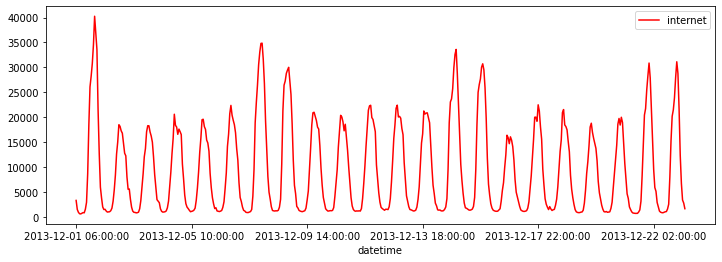

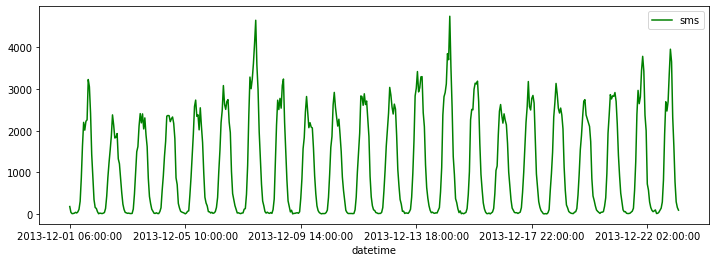

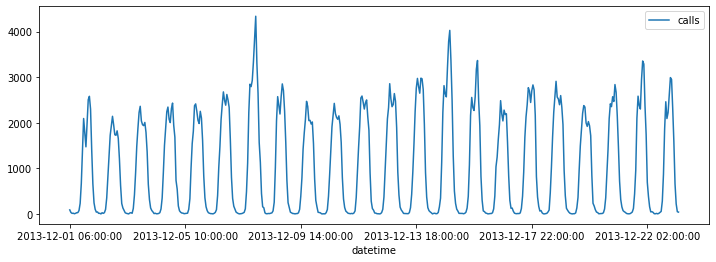

In [10]:
df_5161_inet = df_call[df_call['squareid'] == 5161][['internet']]
df_5161_inet.plot(color='red', figsize=(12,4))

df_5161_sms = df_call[df_call['squareid'] == 5161][['sms']]
df_5161_sms.plot(color='green', figsize=(12,4))

df_5161_call = df_call[df_call['squareid'] == 5161][['calls']]
df_5161_call.plot(figsize=(12,4))

**Checking the data is complete for each timestamp:**

In [11]:
# take the index, containing datetime
date_5161 = df_5161_inet.index

# make a Series of complete date
complete_date = pd.Series(pd.date_range(start=date_5161.min(), end=date_5161.max(), freq='H'))

# compare between complete_date and df_5161_dt
mask = complete_date.isin(date_5161)

# print out all skipped datetime
# if empty, then you are good to go
complete_date[~ mask]

Series([], dtype: datetime64[ns])

The data is complete now, so good to go.

### 2. Generating sample time series dataset

For now, we'll generate time series containing 1000 numbers with seasonality following the sin wave.

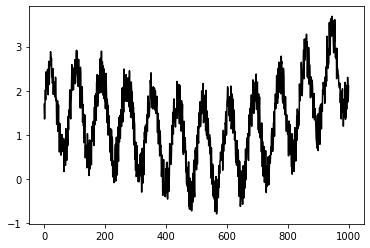

In [12]:
# generate random data
N = 1000 # number of data
t = np.arange(0, N) # time index
x = np.sin(0.075*t) + np.cos(0.005*t) + 0.002*t + np.random.rand(N) # univariate time series
df = pd.DataFrame({'Actual': x})

# plot the data
plt.plot(df, color="black")
plt.show()

### 3. Train-test splitting

In machine learning, train/test split splits the data randomly, as there's no dependence from one observation to the other. That's not the case with time series data. Here, you'll want to use `shuffle=False` so that the values at the rear of the dataset for testing and everything else for training.

In [13]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)
train, test = df_train.values, df_test.values # dataframe to array
print("TRAIN SHAPE:\t", train.shape)
print("TEST SHAPE:\t", test.shape)

TRAIN SHAPE:	 (800, 1)
TEST SHAPE:	 (200, 1)


### 4. Preprocessing

We want to split the last 7 days for data test. Since the dataset datetime contains the details of the time until the hour (dataset divided by time up to hour detail per observation), we multiply 24 hours with 7 days to get the exact observation. Since we will test and train all variables, we wil split the 

In [14]:
df_train_inet, df_test_inet = train_test_split(df_5161_inet, test_size=24*7 , shuffle=False)

In [15]:
df_train_sms, df_test_sms = train_test_split(df_5161_sms, test_size=24*7 , shuffle=False)

In [16]:
df_train_call, df_test_call = train_test_split(df_5161_call, test_size=24*7 , shuffle=False)

**Data Scaling**

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [18]:
scaler = MinMaxScaler()
scaled_train_inet = scaler.fit_transform(df_train_inet)
scaled_test_inet = scaler.transform(df_test_inet)

In [19]:
scaler = MinMaxScaler()
scaled_train_sms = scaler.fit_transform(df_train_sms)
scaled_test_sms = scaler.transform(df_test_sms)

In [20]:
scaler = MinMaxScaler()
scaled_train_call = scaler.fit_transform(df_train_call)
scaled_test_call= scaler.transform(df_test_call)

Lastly, we create the `TimeseriesGenerator`, but remember to use the scaled data.

In [21]:
from keras.preprocessing.sequence import TimeseriesGenerator

look_back = 24*5 #lag predictor: untuk memprediksi 1 jam ke depan, melihat pola data 5 hari ke belakang
train_gen_inet = TimeseriesGenerator(data=scaled_train_inet, targets=scaled_train_inet, length=look_back, batch_size=1)
test_gen_inet = TimeseriesGenerator(data=scaled_test_inet, targets=scaled_test_inet, length=look_back, batch_size=1)

In [22]:
look_back = 24*5 #lag predictor: untuk memprediksi 1 jam ke depan, melihat pola data 5 hari ke belakang
train_gen_sms = TimeseriesGenerator(data=scaled_train_sms, targets=scaled_train_sms, length=look_back, batch_size=1)
test_gen_sms = TimeseriesGenerator(data=scaled_test_inet, targets=scaled_test_sms, length=look_back, batch_size=1)

In [23]:
look_back = 24*5 #lag predictor: untuk memprediksi 1 jam ke depan, melihat pola data 5 hari ke belakang
train_gen_call = TimeseriesGenerator(data=scaled_train_call, targets=scaled_train_call, length=look_back, batch_size=1)
test_gen_call = TimeseriesGenerator(data=scaled_test_call, targets=scaled_test_call, length=look_back, batch_size=1)

### 5. Building the model


For this case, we use [LSTM layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM) instead of SimpleRNN.

In [24]:
def init_model_lstm():
    # define architecture
    model = keras.models.Sequential()
    model.add(keras.layers.LSTM(units=64, input_shape=(look_back, 1)))
    model.add(keras.layers.Dense(units=1, activation='relu'))
    
    # model compile
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

model_lstm = init_model_lstm()
model_lstm.summary()

2022-09-26 09:04:18.681955: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 64)                16896     
_________________________________________________________________
dense (Dense)                (None, 1)                 65        
Total params: 16,961
Trainable params: 16,961
Non-trainable params: 0
_________________________________________________________________


In [25]:
# fitting model internet
model_lstm.fit(train_gen_inet, epochs=10)

Epoch 1/10


2022-09-26 09:04:19.144155: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


240/240 [==============================] - 8s 26ms/step - loss: 0.0374
Epoch 2/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0057
Epoch 3/10
240/240 [==============================] - 7s 28ms/step - loss: 0.0043
Epoch 4/10
240/240 [==============================] - 7s 27ms/step - loss: 0.0047
Epoch 5/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0038
Epoch 6/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0032
Epoch 7/10
240/240 [==============================] - 6s 27ms/step - loss: 0.0032
Epoch 8/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0031
Epoch 9/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0026
Epoch 10/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0029


In [26]:
# fitting model sms
model_lstm.fit(train_gen_sms, epochs=10)

Epoch 1/10
240/240 [==============================] - 7s 27ms/step - loss: 0.0057
Epoch 2/10
240/240 [==============================] - 6s 25ms/step - loss: 0.0046
Epoch 3/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0047
Epoch 4/10
240/240 [==============================] - 7s 27ms/step - loss: 0.0049
Epoch 5/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0047
Epoch 6/10
240/240 [==============================] - 6s 25ms/step - loss: 0.0043
Epoch 7/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0042
Epoch 8/10
240/240 [==============================] - 7s 27ms/step - loss: 0.0045
Epoch 9/10
240/240 [==============================] - 6s 25ms/step - loss: 0.0041
Epoch 10/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0039


In [27]:
# fitting model internet
model_lstm.fit(train_gen_call, epochs=10)

Epoch 1/10
240/240 [==============================] - 6s 27ms/step - loss: 0.0041
Epoch 2/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0038
Epoch 3/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0030
Epoch 4/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0031
Epoch 5/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0027
Epoch 6/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0023
Epoch 7/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0023
Epoch 8/10
240/240 [==============================] - 6s 26ms/step - loss: 0.0021
Epoch 9/10
240/240 [==============================] - 7s 29ms/step - loss: 0.0019
Epoch 10/10
240/240 [==============================] - 6s 25ms/step - loss: 0.0021


Visualize the loss per epoch using `matplotlib`:

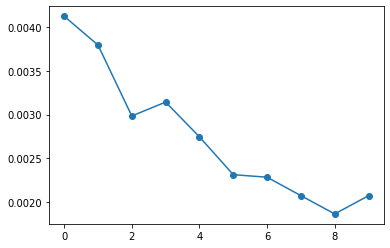

In [28]:
plt.plot(model_lstm.history.history['loss'], marker='o')
plt.show()

### 6. Evaluate the model


In [29]:
scaled_train_predict_inet = model_lstm.predict(train_gen_inet)
train_predict_inet = scaler.inverse_transform(scaled_train_predict_inet)
train_predict_inet.shape

(240, 1)

In [30]:
scaled_train_predict_sms = model_lstm.predict(train_gen_sms)
train_predict_sms = scaler.inverse_transform(scaled_train_predict_sms)
train_predict_sms.shape

(240, 1)

In [31]:
scaled_train_predict_call = model_lstm.predict(train_gen_call)
train_predict_call = scaler.inverse_transform(scaled_train_predict_call)
train_predict_call.shape

(240, 1)

In [32]:
scaled_test_predict_inet = model_lstm.predict(test_gen_inet)
test_predict_inet = scaler.inverse_transform(scaled_test_predict_inet)

In [33]:
scaled_test_predict_call = model_lstm.predict(test_gen_call)
test_predict_call = scaler.inverse_transform(scaled_test_predict_call)

In [34]:
scaled_test_predict_sms = model_lstm.predict(test_gen_sms)
test_predict_sms = scaler.inverse_transform(scaled_test_predict_sms)

### 7. TRAINING DATA

<AxesSubplot:xlabel='datetime'>

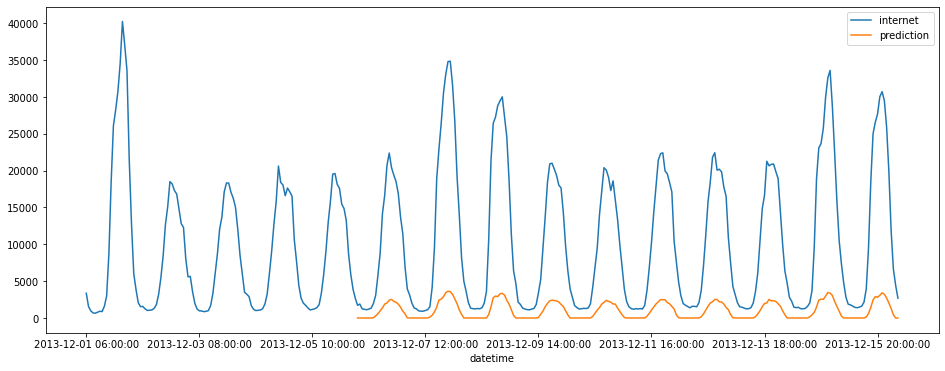

In [35]:
#Internet
# create numpy array containing nan 
temp = np.empty((df_train_inet.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(train_predict_inet):] = train_predict_inet

df_train_inet["prediction"] = temp

# visualize
df_train_inet.plot(figsize=(16, 6))

<AxesSubplot:xlabel='datetime'>

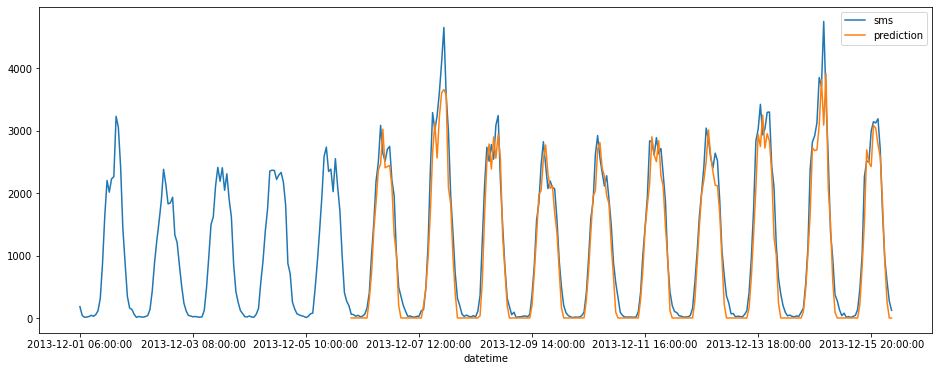

In [36]:
#SMS
# create numpy array containing nan 
temp = np.empty((df_train_sms.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(train_predict_sms):] = train_predict_sms

df_train_sms["prediction"] = temp

# visualize
df_train_sms.plot(figsize=(16, 6))

<AxesSubplot:xlabel='datetime'>

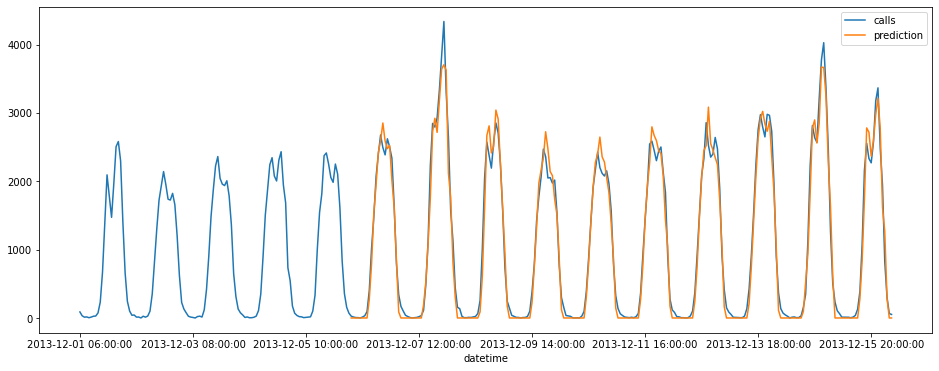

In [37]:
#calls
# create numpy array containing nan 
temp = np.empty((df_train_call.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(train_predict_call):] = train_predict_call

df_train_call["prediction"] = temp

# visualize
df_train_call.plot(figsize=(16, 6))

In [38]:
from sklearn.metrics import mean_squared_error

In [39]:
# TRAIN RMSE Internet
df_train_inet = df_train_inet.dropna()
mean_squared_error(
    y_true=df_train_inet['internet'],
    y_pred=df_train_inet['prediction'],
    squared=False
)

12905.786940758424

In [40]:
# TRAIN RMSE SMS
df_train_sms = df_train_sms.dropna()
mean_squared_error(
    y_true=df_train_sms['sms'],
    y_pred=df_train_sms['prediction'],
    squared=False
)

299.8265731058321

In [41]:
# TRAIN RMSE SMS
df_train_call = df_train_call.dropna()
mean_squared_error(
    y_true=df_train_call['calls'],
    y_pred=df_train_call['prediction'],
    squared=False
)

175.35622753986604

### 8. TESTING DATA

<AxesSubplot:xlabel='datetime'>

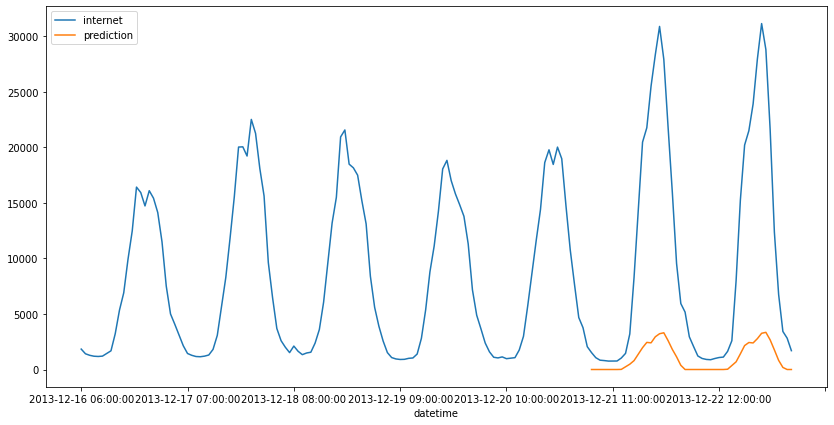

In [42]:
# create numpy array containing nan
temp = np.empty((df_test_inet.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(test_predict_inet):] = test_predict_inet

df_test_inet["prediction"] = temp

# visualize
df_test_inet.plot(figsize=(14, 7))

<AxesSubplot:xlabel='datetime'>

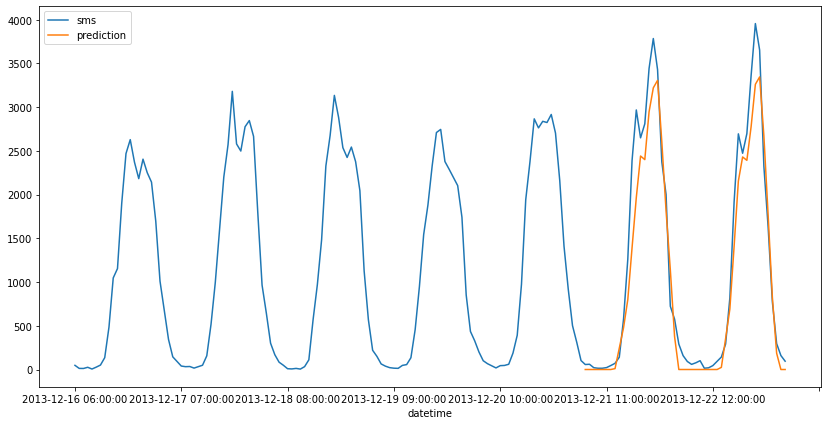

In [43]:
# create numpy array containing nan
temp = np.empty((df_test_sms.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(test_predict_sms):] = test_predict_sms
df_test_sms["prediction"] = temp

# visualize
df_test_sms.plot(figsize=(14, 7))

<AxesSubplot:xlabel='datetime'>

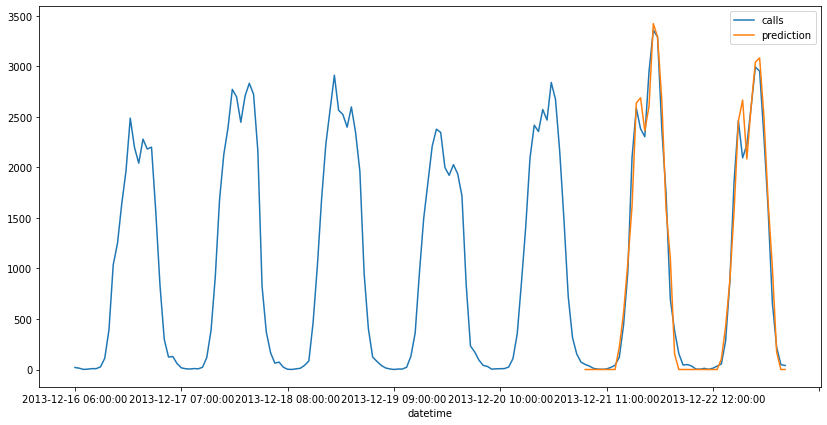

In [44]:
# create numpy array containing nan
temp = np.empty((df_test_call.shape[0], 1))
temp[:] = np.nan

# fill the array with train_predict
temp[-len(test_predict_call):] = test_predict_call

df_test_call["prediction"] = temp

# visualize
df_test_call.plot(figsize=(14, 7))

In [45]:
# TEST RMSE Internet
df_test_inet = df_test_inet.dropna()
mean_squared_error(
    y_true=df_test_inet['internet'],
    y_pred=df_test_inet['prediction'],
    squared=False #agar mengembalikan root mean squared error
)

13080.644499089462

In [46]:
# TEST RMSE SMS
df_test_sms = df_test_sms.dropna()
mean_squared_error(
    y_true=df_test_sms['sms'],
    y_pred=df_test_sms['prediction'],
    squared=False #agar mengembalikan root mean squared error
)

331.19367045949554

In [47]:
# TEST RMSE Calls
df_test_call = df_test_call.dropna()
mean_squared_error(
    y_true=df_test_call['calls'],
    y_pred=df_test_call['prediction'],
    squared=False #agar mengembalikan root mean squared error
)

176.43676209192324

### 9. Prediction for future dates

In [48]:
look_ahead = 24*3

In [49]:
from pandas.tseries.offsets import DateOffset

In [50]:
df_5161_inet.index

Index(['2013-12-01 06:00:00', '2013-12-01 07:00:00', '2013-12-01 08:00:00',
       '2013-12-01 09:00:00', '2013-12-01 10:00:00', '2013-12-01 11:00:00',
       '2013-12-01 12:00:00', '2013-12-01 13:00:00', '2013-12-01 14:00:00',
       '2013-12-01 15:00:00',
       ...
       '2013-12-22 20:00:00', '2013-12-22 21:00:00', '2013-12-22 22:00:00',
       '2013-12-22 23:00:00', '2013-12-23 00:00:00', '2013-12-23 01:00:00',
       '2013-12-23 02:00:00', '2013-12-23 03:00:00', '2013-12-23 04:00:00',
       '2013-12-23 05:00:00'],
      dtype='object', name='datetime', length=528)

Need to reindex

In [51]:
inet_5161_reindex = df_5161_inet.reindex(complete_date)

In [52]:
inet_5161_reindex.index

DatetimeIndex(['2013-12-01 06:00:00', '2013-12-01 07:00:00',
               '2013-12-01 08:00:00', '2013-12-01 09:00:00',
               '2013-12-01 10:00:00', '2013-12-01 11:00:00',
               '2013-12-01 12:00:00', '2013-12-01 13:00:00',
               '2013-12-01 14:00:00', '2013-12-01 15:00:00',
               ...
               '2013-12-22 20:00:00', '2013-12-22 21:00:00',
               '2013-12-22 22:00:00', '2013-12-22 23:00:00',
               '2013-12-23 00:00:00', '2013-12-23 01:00:00',
               '2013-12-23 02:00:00', '2013-12-23 03:00:00',
               '2013-12-23 04:00:00', '2013-12-23 05:00:00'],
              dtype='datetime64[ns]', length=528, freq=None)

In [53]:
# create future dates Internet
add_dates_inet = [inet_5161_reindex.index[-1] + DateOffset(hours=x) for x in range(look_ahead+1)]
future_dates_inet = pd.DataFrame(index=add_dates_inet[1:])
future_dates_inet

""
2013-12-23 06:00:00
2013-12-23 07:00:00
2013-12-23 08:00:00
2013-12-23 09:00:00
2013-12-23 10:00:00
...
2013-12-26 01:00:00
2013-12-26 02:00:00
2013-12-26 03:00:00
2013-12-26 04:00:00


In [54]:
# create future dates SMS
add_dates_sms = [inet_5161_reindex.index[-1] + DateOffset(hours=x) for x in range(look_ahead+1)]
future_dates_sms = pd.DataFrame(index=add_dates_sms[1:])
future_dates_sms

""
2013-12-23 06:00:00
2013-12-23 07:00:00
2013-12-23 08:00:00
2013-12-23 09:00:00
2013-12-23 10:00:00
...
2013-12-26 01:00:00
2013-12-26 02:00:00
2013-12-26 03:00:00
2013-12-26 04:00:00


In [55]:
# create future dates Calls
add_dates_call = [inet_5161_reindex.index[-1] + DateOffset(hours=x) for x in range(look_ahead+1)]
future_dates_call = pd.DataFrame(index=add_dates_call[1:])
future_dates_call

""
2013-12-23 06:00:00
2013-12-23 07:00:00
2013-12-23 08:00:00
2013-12-23 09:00:00
2013-12-23 10:00:00
...
2013-12-26 01:00:00
2013-12-26 02:00:00
2013-12-26 03:00:00
2013-12-26 04:00:00


In order to predict future value (after testing data), we have to manually create a loop to feed the network. 

In [56]:
def forecast_future(trained_model, data, look_back, n_features, look_ahead):
    prediction_list = []
    current_batch = data[-look_back:].reshape((1, look_back, n_features))
    
    for i in range(look_ahead):
        # get the prediction value for the first batch
        current_pred = trained_model.predict(current_batch)[0]

        # append the prediction into the list
        prediction_list.append(current_pred)

        # use the prediction to update the batch and remove the first value
        current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)
        
    return np.array(prediction_list)

In [57]:
scaled_future_inet = forecast_future(trained_model=model_lstm,
                                data=scaled_test_inet, #data aktual paling belakang
                                look_back=look_back, #24 * 5
                                n_features=1, #univariate
                                look_ahead=look_ahead) #24*3

In [58]:
scaled_future_sms = forecast_future(trained_model=model_lstm,
                                data=scaled_test_sms, #data aktual paling belakang
                                look_back=look_back, #24 * 5
                                n_features=1, #univariate
                                look_ahead=look_ahead) #24*3

In [59]:
scaled_future_call = forecast_future(trained_model=model_lstm,
                                data=scaled_test_call, #data aktual paling belakang
                                look_back=look_back, #24 * 5
                                n_features=1, #univariate
                                look_ahead=look_ahead) #24*3

In [60]:
future_dates_inet['future'] = scaler.inverse_transform(scaled_future_inet)

In [61]:
future_dates_inet

,future
2013-12-23 06:00:00,0.408902
2013-12-23 07:00:00,0.408902
2013-12-23 08:00:00,0.408902
2013-12-23 09:00:00,0.408902
2013-12-23 10:00:00,0.408902
...,...
2013-12-26 01:00:00,2561.743164
2013-12-26 02:00:00,1852.520996
2013-12-26 03:00:00,1124.593872
2013-12-26 04:00:00,416.185089


In [62]:
future_dates_sms['future'] = scaler.inverse_transform(scaled_future_sms)

In [63]:
future_dates_sms

,future
2013-12-23 06:00:00,0.408902
2013-12-23 07:00:00,0.408902
2013-12-23 08:00:00,0.408902
2013-12-23 09:00:00,0.408902
2013-12-23 10:00:00,0.408902
...,...
2013-12-26 01:00:00,2551.784912
2013-12-26 02:00:00,1840.270630
2013-12-26 03:00:00,1112.423096
2013-12-26 04:00:00,403.871826


In [64]:
future_dates_call['future'] = scaler.inverse_transform(scaled_future_call)

In [65]:
future_dates_call

,future
2013-12-23 06:00:00,0.408902
2013-12-23 07:00:00,0.408902
2013-12-23 08:00:00,0.408902
2013-12-23 09:00:00,0.408902
2013-12-23 10:00:00,0.408902
...,...
2013-12-26 01:00:00,2510.903076
2013-12-26 02:00:00,1794.025513
2013-12-26 03:00:00,1068.265137
2013-12-26 04:00:00,359.747650


<AxesSubplot:>

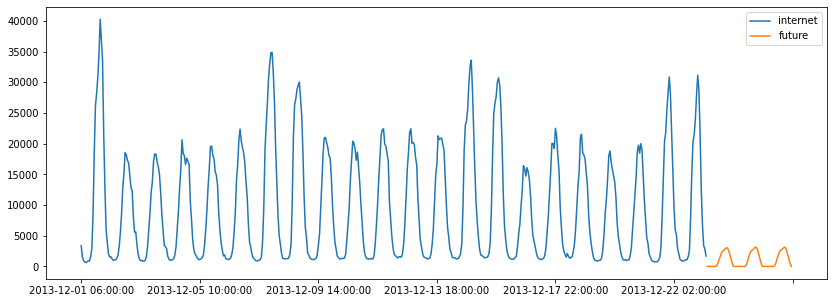

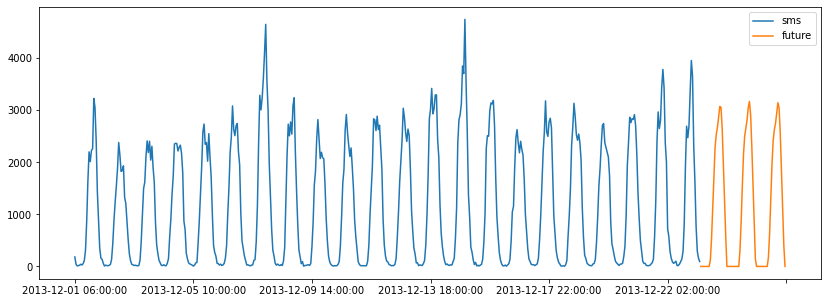

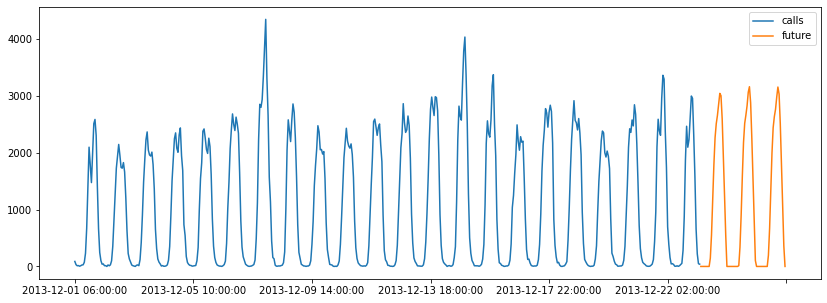

In [66]:
pd.concat([df_5161_inet, future_dates_inet], axis=1).plot(figsize=(14, 5))
pd.concat([df_5161_sms, future_dates_sms], axis=1).plot(figsize=(14, 5))
pd.concat([df_5161_call, future_dates_call], axis=1).plot(figsize=(14, 5))